# EV ChargeOps - Sprint 2

## Enterprise Challenge 2026

Protótipo funcional para gerenciamento de sessões de recarga de veículos elétricos em infraestrutura compartilhada.

### Objetivos principais
- Registrar sessões de recarga
- Calcular consumo individual
- Aplicar modelo de rateio
- Gerar indicadores operacionais
- Implementar módulo de inteligência artificial
- Detectar padrões e anomalias de consumo
- Apoiar a tomada de decisão do gestor


In [1]:
import pandas as pd #dados principais do EV ChargeOps

dados = {
    "sessao_id": [1, 2, 3, 4, 5, 6, 7, 8],
    "usuario": [
        "Carlos", "Mariana", "Carlos", "João",
        "Mariana", "Ana", "João", "Ana"
    ],
    "unidade": [
        "Apto 101", "Apto 202", "Apto 101", "Apto 303",
        "Apto 202", "Apto 404", "Apto 303", "Apto 404"
    ],
    "veiculo": [
        "BYD Dolphin", "Volvo EX30", "BYD Dolphin", "GWM Ora 03",
        "Volvo EX30", "Renault Kwid E-Tech", "GWM Ora 03", "Renault Kwid E-Tech"
    ],
    "energia_kwh": [18.4, 24.7, 15.2, 31.5, 22.1, 12.8, 29.4, 16.7],
    "duracao_horas": [2.1, 3.0, 1.8, 4.2, 2.7, 1.6, 3.8, 2.0],
    "tarifa_kwh": [0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95]
}

df = pd.DataFrame(dados)

df["custo_sessao"] = df["energia_kwh"] * df["tarifa_kwh"]

display(df)

,sessao_id,usuario,unidade,veiculo,energia_kwh,duracao_horas,tarifa_kwh,custo_sessao
0,1,Carlos,Apto 101,BYD Dolphin,18.4,2.1,0.95,17.480
1,2,Mariana,Apto 202,Volvo EX30,24.7,3.0,0.95,23.465
2,3,Carlos,Apto 101,BYD Dolphin,15.2,1.8,0.95,14.440
3,4,João,Apto 303,GWM Ora 03,31.5,4.2,0.95,29.925
4,5,Mariana,Apto 202,Volvo EX30,22.1,2.7,0.95,20.995
5,6,Ana,Apto 404,Renault Kwid E-Tech,12.8,1.6,0.95,12.160
6,7,João,Apto 303,GWM Ora 03,29.4,3.8,0.95,27.930
7,8,Ana,Apto 404,Renault Kwid E-Tech,16.7,2.0,0.95,15.865


In [2]:
# Resumo de consumo e custo por usuário
# consumo individual + rateio.

resumo_usuario = (
    df.groupby(["usuario", "unidade"])
    .agg(
        total_sessoes=("sessao_id", "count"),
        consumo_total_kwh=("energia_kwh", "sum"),
        custo_total=("custo_sessao", "sum"),
        duracao_total_horas=("duracao_horas", "sum")
    )
    .reset_index()
)

resumo_usuario["custo_total"] = resumo_usuario["custo_total"].round(2)
resumo_usuario["consumo_total_kwh"] = resumo_usuario["consumo_total_kwh"].round(2)
resumo_usuario["duracao_total_horas"] = resumo_usuario["duracao_total_horas"].round(2)

print("Rateio por usuário/unidade:")
display(resumo_usuario)

Rateio por usuário/unidade:


,usuario,unidade,total_sessoes,consumo_total_kwh,custo_total,duracao_total_horas
0,Ana,Apto 404,2,29.5,28.02,3.6
1,Carlos,Apto 101,2,33.6,31.92,3.9
2,João,Apto 303,2,60.9,57.85,8.0
3,Mariana,Apto 202,2,46.8,44.46,5.7


In [3]:
# Indicadores operacionais do EV ChargeOps

consumo_total = df["energia_kwh"].sum()
custo_total = df["custo_sessao"].sum()
total_sessoes = df["sessao_id"].count()
consumo_medio = df["energia_kwh"].mean()
duracao_media = df["duracao_horas"].mean()

print("INDICADORES OPERACIONAIS")
print("------------------------")
print(f"Total de sessões: {total_sessoes}")
print(f"Consumo total: {consumo_total:.2f} kWh")
print(f"Custo total: R$ {custo_total:.2f}")
print(f"Consumo médio por sessão: {consumo_medio:.2f} kWh")
print(f"Duração média por sessão: {duracao_media:.2f} horas")

INDICADORES OPERACIONAIS
------------------------
Total de sessões: 8
Consumo total: 170.80 kWh
Custo total: R$ 162.26
Consumo médio por sessão: 21.35 kWh
Duração média por sessão: 2.65 horas


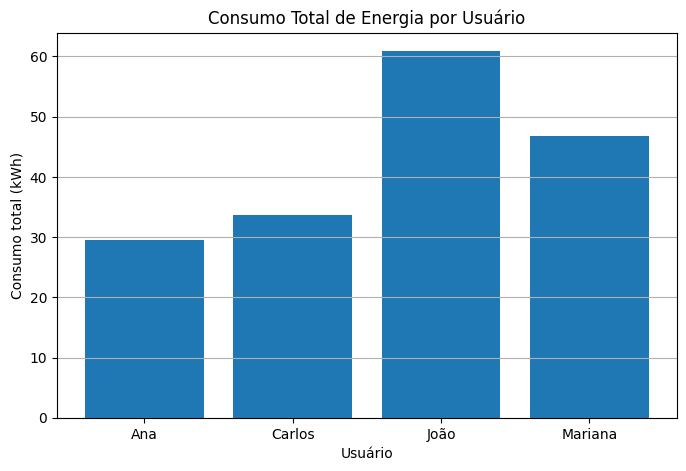

In [4]:
# Gráfico de consumo por usuário

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    resumo_usuario["usuario"],
    resumo_usuario["consumo_total_kwh"]
)

plt.title("Consumo Total de Energia por Usuário")
plt.xlabel("Usuário")
plt.ylabel("Consumo total (kWh)")
plt.grid(axis="y")

plt.show()

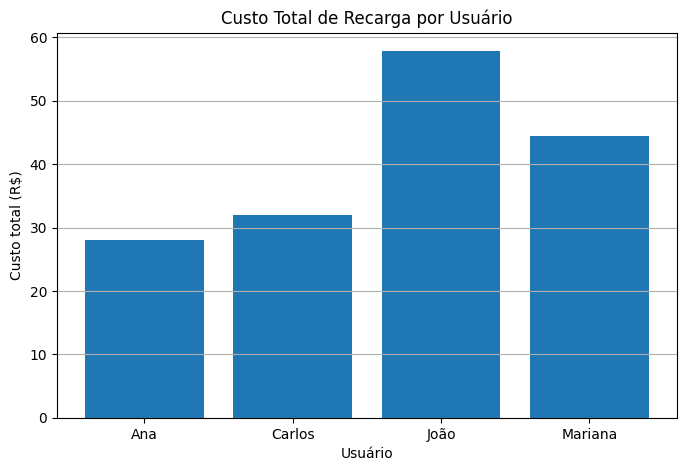

In [5]:
# Gráfico de custo total por usuário

plt.figure(figsize=(8, 5))

plt.bar(
    resumo_usuario["usuario"],
    resumo_usuario["custo_total"]
)

plt.title("Custo Total de Recarga por Usuário")
plt.xlabel("Usuário")
plt.ylabel("Custo total (R$)")
plt.grid(axis="y")

plt.show()

In [6]:
# Modelo de IA para detecção de anomalias com Isolation Forest

# IA real integrada ao fluxo do sistema, analisando as sessões de recarga com base em consumo e duração.

from sklearn.ensemble import IsolationForest

# Selecionando variáveis para análise
dados_ia = df[["energia_kwh", "duracao_horas"]]

# Criando o modelo
modelo_ia = IsolationForest(
    contamination=0.25,
    random_state=42
)

# Treinando o modelo
df["classificacao_ia"] = modelo_ia.fit_predict(dados_ia)

# Convertendo resultado para texto
df["resultado_ia"] = df["classificacao_ia"].apply(
    lambda x: "Anômala" if x == -1 else "Normal"
)

print("Resultado da análise por Inteligência Artificial:")

display(
    df[
        [
            "sessao_id",
            "usuario",
            "energia_kwh",
            "duracao_horas",
            "resultado_ia"
        ]
    ]
)

Resultado da análise por Inteligência Artificial:


,sessao_id,usuario,energia_kwh,duracao_horas,resultado_ia
0,1,Carlos,18.4,2.1,Normal
1,2,Mariana,24.7,3.0,Normal
2,3,Carlos,15.2,1.8,Normal
3,4,João,31.5,4.2,Anômala
4,5,Mariana,22.1,2.7,Normal
5,6,Ana,12.8,1.6,Anômala
6,7,João,29.4,3.8,Normal
7,8,Ana,16.7,2.0,Normal


In [7]:
# Classificação de risco das sessões

def classificar_risco(linha):
    if linha["resultado_ia"] == "Anômala" and linha["energia_kwh"] > df["energia_kwh"].mean():
        return "ALTO"
    elif linha["resultado_ia"] == "Anômala":
        return "MÉDIO"
    else:
        return "BAIXO"

df["nivel_risco"] = df.apply(classificar_risco, axis=1)

print("Classificação de risco das sessões:")

display(
    df[
        [
            "sessao_id",
            "usuario",
            "energia_kwh",
            "duracao_horas",
            "resultado_ia",
            "nivel_risco"
        ]
    ]
)

Classificação de risco das sessões:


,sessao_id,usuario,energia_kwh,duracao_horas,resultado_ia,nivel_risco
0,1,Carlos,18.4,2.1,Normal,BAIXO
1,2,Mariana,24.7,3.0,Normal,BAIXO
2,3,Carlos,15.2,1.8,Normal,BAIXO
3,4,João,31.5,4.2,Anômala,ALTO
4,5,Mariana,22.1,2.7,Normal,BAIXO
5,6,Ana,12.8,1.6,Anômala,MÉDIO
6,7,João,29.4,3.8,Normal,BAIXO
7,8,Ana,16.7,2.0,Normal,BAIXO


In [8]:
# Classificação de risco das sessões

def classificar_risco(linha):
    if linha["resultado_ia"] == "Anômala" and linha["energia_kwh"] > df["energia_kwh"].mean():
        return "ALTO"
    elif linha["resultado_ia"] == "Anômala":
        return "MÉDIO"
    else:
        return "BAIXO"

df["nivel_risco"] = df.apply(classificar_risco, axis=1)

print("Classificação de risco das sessões:")

display(
    df[
        [
            "sessao_id",
            "usuario",
            "energia_kwh",
            "duracao_horas",
            "resultado_ia",
            "nivel_risco"
        ]
    ]
)

Classificação de risco das sessões:


,sessao_id,usuario,energia_kwh,duracao_horas,resultado_ia,nivel_risco
0,1,Carlos,18.4,2.1,Normal,BAIXO
1,2,Mariana,24.7,3.0,Normal,BAIXO
2,3,Carlos,15.2,1.8,Normal,BAIXO
3,4,João,31.5,4.2,Anômala,ALTO
4,5,Mariana,22.1,2.7,Normal,BAIXO
5,6,Ana,12.8,1.6,Anômala,MÉDIO
6,7,João,29.4,3.8,Normal,BAIXO
7,8,Ana,16.7,2.0,Normal,BAIXO


In [9]:
# Recomendações automáticas com base no nível de risco

def gerar_recomendacao(linha):
    if linha["nivel_risco"] == "ALTO":
        return "Verificar sessão e consumo imediatamente"
    elif linha["nivel_risco"] == "MÉDIO":
        return "Acompanhar próximas sessões do usuário"
    else:
        return "Nenhuma ação necessária"

df["recomendacao"] = df.apply(gerar_recomendacao, axis=1)

print("Recomendações geradas pelo EV ChargeOps:")

display(
    df[
        [
            "sessao_id",
            "usuario",
            "resultado_ia",
            "nivel_risco",
            "recomendacao"
        ]
    ]
)

Recomendações geradas pelo EV ChargeOps:


,sessao_id,usuario,resultado_ia,nivel_risco,recomendacao
0,1,Carlos,Normal,BAIXO,Nenhuma ação necessária
1,2,Mariana,Normal,BAIXO,Nenhuma ação necessária
2,3,Carlos,Normal,BAIXO,Nenhuma ação necessária
3,4,João,Anômala,ALTO,Verificar sessão e consumo imediatamente
4,5,Mariana,Normal,BAIXO,Nenhuma ação necessária
5,6,Ana,Anômala,MÉDIO,Acompanhar próximas sessões do usuário
6,7,João,Normal,BAIXO,Nenhuma ação necessária
7,8,Ana,Normal,BAIXO,Nenhuma ação necessária


In [10]:
# Painel-resumo do gestor

total_sessoes = len(df)
total_anomalias = (df["resultado_ia"] == "Anômala").sum()
total_risco_alto = (df["nivel_risco"] == "ALTO").sum()
consumo_total = df["energia_kwh"].sum()
custo_total = df["custo_sessao"].sum()

print("PAINEL DO GESTOR - EV CHARGEOPS")
print("--------------------------------")
print(f"Total de sessões: {total_sessoes}")
print(f"Consumo total: {consumo_total:.2f} kWh")
print(f"Custo total: R$ {custo_total:.2f}")
print(f"Sessões anômalas: {total_anomalias}")
print(f"Sessões com risco alto: {total_risco_alto}")

print("\nSessões que exigem atenção:")

display(
    df[df["nivel_risco"].isin(["ALTO", "MÉDIO"])][
        [
            "sessao_id",
            "usuario",
            "energia_kwh",
            "resultado_ia",
            "nivel_risco",
            "recomendacao"
        ]
    ]
)

PAINEL DO GESTOR - EV CHARGEOPS
--------------------------------
Total de sessões: 8
Consumo total: 170.80 kWh
Custo total: R$ 162.26
Sessões anômalas: 2
Sessões com risco alto: 1

Sessões que exigem atenção:


,sessao_id,usuario,energia_kwh,resultado_ia,nivel_risco,recomendacao
3,4,João,31.5,Anômala,ALTO,Verificar sessão e consumo imediatamente
5,6,Ana,12.8,Anômala,MÉDIO,Acompanhar próximas sessões do usuário


In [11]:
# Previsão simples de consumo com Machine Learning

from sklearn.linear_model import LinearRegression

# Variável de entrada: duração da recarga
X = df[["duracao_horas"]]

# Variável que queremos prever: consumo de energia
y = df["energia_kwh"]

# Criando e treinando o modelo
modelo_previsao = LinearRegression()
modelo_previsao.fit(X, y)

# Previsões para as sessões existentes
df["consumo_previsto_kwh"] = modelo_previsao.predict(X)

# Arredondando os valores
df["consumo_previsto_kwh"] = df["consumo_previsto_kwh"].round(2)

print("Previsão de consumo por sessão:")

display(
    df[
        [
            "sessao_id",
            "usuario",
            "duracao_horas",
            "energia_kwh",
            "consumo_previsto_kwh"
        ]
    ]
)

Previsão de consumo por sessão:


,sessao_id,usuario,duracao_horas,energia_kwh,consumo_previsto_kwh
0,1,Carlos,2.1,18.4,17.48
1,2,Mariana,3.0,24.7,23.81
2,3,Carlos,1.8,15.2,15.37
3,4,João,4.2,31.5,32.26
4,5,Mariana,2.7,22.1,21.70
5,6,Ana,1.6,12.8,13.96
6,7,João,3.8,29.4,29.44
7,8,Ana,2.0,16.7,16.77


In [12]:
# Avaliação da previsão de consumo

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_real = df["energia_kwh"]
y_previsto = df["consumo_previsto_kwh"]

mae = mean_absolute_error(y_real, y_previsto)
mse = mean_squared_error(y_real, y_previsto)
rmse = np.sqrt(mse)
r2 = r2_score(y_real, y_previsto)

print("AVALIAÇÃO DO MODELO DE PREVISÃO")
print("--------------------------------")
print(f"MAE: {mae:.2f} kWh")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f} kWh")
print(f"R²: {r2:.2f}")

AVALIAÇÃO DO MODELO DE PREVISÃO
--------------------------------
MAE: 0.55 kWh
MSE: 0.47
RMSE: 0.69 kWh
R²: 0.99


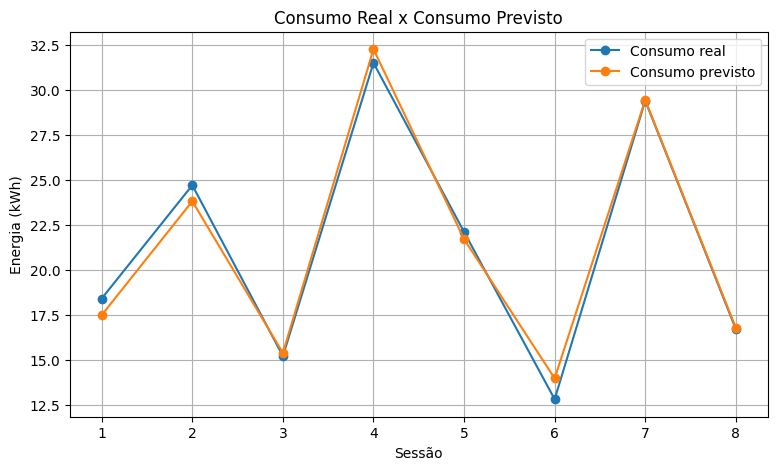

In [13]:
# Comparação entre consumo real e consumo previsto

import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    df["sessao_id"],
    df["energia_kwh"],
    marker="o",
    label="Consumo real"
)

plt.plot(
    df["sessao_id"],
    df["consumo_previsto_kwh"],
    marker="o",
    label="Consumo previsto"
)

plt.title("Consumo Real x Consumo Previsto")
plt.xlabel("Sessão")
plt.ylabel("Energia (kWh)")
plt.legend()
plt.grid()

plt.show()

In [14]:
# Exportação dos resultados finais

df.to_csv(
    "ev_chargeops_resultados.csv",
    index=False
)

print("Arquivo ev_chargeops_resultados.csv criado com sucesso!")

Arquivo ev_chargeops_resultados.csv criado com sucesso!


## Conclusão Técnica

O protótipo EV ChargeOps foi desenvolvido para transformar sessões de recarga de veículos elétricos em informações estruturadas e úteis para gestão.

A solução implementada permite registrar sessões, calcular consumo individual, realizar o rateio de custos e gerar indicadores operacionais.

Também foi implementado um módulo de Inteligência Artificial com duas funções principais:

- detecção de anomalias utilizando Isolation Forest;
- previsão de consumo utilizando Regressão Linear.

A partir dos resultados da IA, o sistema classifica níveis de risco e gera recomendações para apoiar a tomada de decisão do gestor.

Foram também utilizados indicadores operacionais, gráficos comparativos e métricas de avaliação como MAE, MSE, RMSE e R².

O protótipo demonstra que os dados de recarga podem ser utilizados não apenas para cobrança, mas também para monitoramento, identificação de padrões e geração de inteligência operacional.

Como evolução futura, o sistema pode ser integrado a dados reais do carregador GoodWe HCA G2, banco de dados em nuvem, autenticação de usuários e dashboards em tempo real.